# Lab 9. Geometry of Embedding Spaces

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/wanghemath/Book-MathNLP/blob/main/labs/chapter-09-geometry-of-embeddings.ipynb)

This lab accompanies Chapter 9 of **Mathematical Natural Language Processing**.

In earlier labs, embeddings were introduced as vectors. In this lab, we study the **geometry** of those vectors:

$$
\text{tokens or documents} \longrightarrow \text{embedding vectors} \longrightarrow \text{distances, angles, projections, clusters, and directions}.
$$

The main message is that the phrase “two words are close” is not complete until we specify the representation, the metric, and the preprocessing.


## Learning goals

By the end of this lab, you should be able to:

1. treat an embedding table as a point cloud $X \in R^{n \times m}$;
2. compute inner-product similarity, cosine similarity, and Euclidean distance;
3. explain why nearest-neighbor rankings change after normalization;
4. use centering to diagnose anisotropy in an embedding space;
5. compute PCA coordinates from the singular value decomposition;
6. implement a small $k$-means algorithm from scratch;
7. explain distance concentration and hubness in high dimensions;
8. construct and test a semantic direction using vector differences;
9. apply projection to remove one linear direction from embeddings;
10. write a short metric audit for an embedding-based NLP system.


## Mathematical background before programming

Let $V=\{w_1,\dots,w_n\}$ be a vocabulary. An embedding model assigns a vector

$$
e_{w_i}\in R^m
$$

to each token $w_i$. Stacking these row vectors gives an embedding matrix

$$
X =
\begin{bmatrix}
- & e_{w_1}^T & -\\
- & e_{w_2}^T & -\\
& \vdots & \\
- & e_{w_n}^T & -
\end{bmatrix}
\in R^{n\times m}.
$$

Thus an embedding space is a finite point cloud in $R^m$.

For vectors $x,y\in R^m$:

**Inner product**

$$
\langle x,y\rangle=x^Ty.
$$

The inner product depends on both direction and vector length.

**Euclidean distance**

$$
\|x-y\|_2=\left(\sum_{j=1}^m (x_j-y_j)^2\right)^{1/2}.
$$

This treats embeddings as points.

**Cosine similarity**

$$
\cos(x,y)=\frac{x^Ty}{\|x\|_2\|y\|_2}.
$$

This depends only on the angle between nonzero vectors.

A very useful identity is this: if $u$ and $v$ are unit vectors, then

$$
\|u-v\|_2^2 = 2-2u^Tv = 2-2\cos(u,v).
$$

So after length-normalization, Euclidean nearest neighbors and cosine nearest neighbors are equivalent.


## Setup

This lab uses only `numpy`, `pandas`, and `matplotlib`. The examples are small enough to run quickly in Google Colab.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

rng = np.random.default_rng(7243)
pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 120)

print("Setup complete.")


Setup complete.


# Part 1. A toy embedding space

Real embedding models may use hundreds or thousands of dimensions. For learning, we construct a small embedding table where the hidden semantic coordinates are easy to inspect.

The coordinates below are not meant to be realistic. They are designed to show several geometric effects clearly:

- semantic groups such as animals, vehicles, royalty, school, and medicine;
- a common direction shared by many words;
- unequal vector norms, which affect inner-product search.


In [2]:
words = [
    "cat", "dog", "lion", "kitten", "puppy",
    "car", "truck", "bus", "road", "engine",
    "king", "queen", "prince", "princess", "throne",
    "student", "teacher", "lecture", "exam", "university",
    "doctor", "nurse", "patient", "hospital", "medicine",
    "book", "books", "city", "cities", "child", "children"
]

# Coordinates: animal, vehicle, royal, school, medical, object/place, plural, youth/family
base = {
    "cat":        [1.00, 0.00, 0.00, 0.05, 0.00, 0.10, 0.00, 0.20],
    "dog":        [1.00, 0.00, 0.00, 0.05, 0.00, 0.05, 0.00, 0.20],
    "lion":       [1.25, 0.00, 0.25, 0.00, 0.00, 0.00, 0.00, 0.05],
    "kitten":     [0.95, 0.00, 0.00, 0.02, 0.00, 0.05, 0.00, 0.75],
    "puppy":      [0.95, 0.00, 0.00, 0.02, 0.00, 0.02, 0.00, 0.75],
    "car":        [0.00, 1.00, 0.00, 0.00, 0.00, 0.15, 0.00, 0.00],
    "truck":      [0.00, 1.10, 0.00, 0.00, 0.00, 0.12, 0.00, 0.00],
    "bus":        [0.00, 0.95, 0.00, 0.08, 0.00, 0.15, 0.00, 0.00],
    "road":       [0.00, 0.70, 0.00, 0.00, 0.00, 0.65, 0.00, 0.00],
    "engine":     [0.00, 0.90, 0.00, 0.00, 0.00, 0.40, 0.00, 0.00],
    "king":       [0.00, 0.00, 1.05, 0.00, 0.00, 0.05, 0.00, 0.15],
    "queen":      [0.00, 0.00, 1.05, 0.00, 0.00, 0.05, 0.00, 0.15],
    "prince":     [0.00, 0.00, 0.95, 0.00, 0.00, 0.05, 0.00, 0.55],
    "princess":   [0.00, 0.00, 0.95, 0.00, 0.00, 0.05, 0.00, 0.55],
    "throne":     [0.00, 0.00, 0.85, 0.00, 0.00, 0.45, 0.00, 0.00],
    "student":    [0.00, 0.00, 0.00, 1.00, 0.00, 0.05, 0.00, 0.30],
    "teacher":    [0.00, 0.00, 0.00, 1.00, 0.00, 0.05, 0.00, 0.05],
    "lecture":    [0.00, 0.00, 0.00, 0.90, 0.00, 0.45, 0.00, 0.00],
    "exam":       [0.00, 0.00, 0.00, 0.85, 0.00, 0.40, 0.00, 0.00],
    "university": [0.00, 0.00, 0.00, 1.10, 0.00, 0.45, 0.00, 0.00],
    "doctor":     [0.00, 0.00, 0.00, 0.05, 1.00, 0.05, 0.00, 0.00],
    "nurse":      [0.00, 0.00, 0.00, 0.05, 1.00, 0.05, 0.00, 0.00],
    "patient":    [0.05, 0.00, 0.00, 0.00, 0.95, 0.05, 0.00, 0.05],
    "hospital":   [0.00, 0.00, 0.00, 0.00, 0.95, 0.50, 0.00, 0.00],
    "medicine":   [0.00, 0.00, 0.00, 0.00, 1.10, 0.35, 0.00, 0.00],
    "book":       [0.00, 0.00, 0.00, 0.35, 0.00, 0.75, 0.00, 0.00],
    "books":      [0.00, 0.00, 0.00, 0.35, 0.00, 0.75, 0.85, 0.00],
    "city":       [0.00, 0.25, 0.00, 0.10, 0.00, 0.90, 0.00, 0.00],
    "cities":     [0.00, 0.25, 0.00, 0.10, 0.00, 0.90, 0.85, 0.00],
    "child":      [0.25, 0.00, 0.00, 0.25, 0.00, 0.05, 0.00, 0.95],
    "children":   [0.25, 0.00, 0.00, 0.25, 0.00, 0.05, 0.85, 0.95],
}

X_semantic = np.array([base[w] for w in words], dtype=float)

# Add a common direction to imitate anisotropy: many real embeddings share a large mean component.
common_direction = np.array([0.35, 0.30, 0.25, 0.30, 0.25, 0.35, 0.20, 0.25])
noise = rng.normal(scale=0.025, size=X_semantic.shape)
X = X_semantic + common_direction + noise

# Create a version with unequal norms to illustrate inner-product sensitivity.
scale = np.ones(len(words))
for w, s in {"lion": 1.45, "university": 1.55, "hospital": 1.50, "throne": 1.40, "truck": 1.30}.items():
    scale[words.index(w)] = s
X_scaled = X * scale[:, None]

embedding_df = pd.DataFrame(X_scaled, index=words, columns=[f"dim_{j+1}" for j in range(X.shape[1])])
embedding_df.head(10).round(3)


,dim_1,dim_2,dim_3,dim_4,dim_5,dim_6,dim_7,dim_8
cat,1.329,0.324,0.215,0.326,0.270,0.494,0.203,0.434
dog,1.354,0.300,0.266,0.332,0.274,0.374,0.192,0.446
lion,2.296,0.466,0.691,0.463,0.299,0.483,0.258,0.466
kitten,1.327,0.252,0.248,0.335,0.249,0.392,0.170,1.034
puppy,1.292,0.297,0.233,0.346,0.230,0.372,0.194,0.991
car,0.350,1.307,0.260,0.326,0.263,0.459,0.192,0.244
truck,0.418,1.795,0.320,0.437,0.340,0.664,0.240,0.320
bus,0.350,1.267,0.209,0.344,0.282,0.493,0.186,0.252
road,0.307,1.010,0.284,0.315,0.302,1.003,0.203,0.268
engine,0.363,1.189,0.236,0.278,0.250,0.741,0.163,0.228


## Norms matter

The norm $\|x\|_2$ of an embedding can affect retrieval. Inner-product search often favors large-norm vectors.


In [3]:
norms = np.linalg.norm(X_scaled, axis=1)
norm_table = pd.DataFrame({"word": words, "norm": norms}).sort_values("norm", ascending=False)
norm_table.head(10).round(3)


,word,norm
19,university,2.649
2,lion,2.605
23,hospital,2.460
14,throne,2.136
6,truck,2.099
30,children,1.931
28,cities,1.847
3,kitten,1.820
26,books,1.794
4,puppy,1.773


# Part 2. Similarity measures and nearest neighbors

We now implement three scoring rules:

$$
s_{inner}(x,y)=x^Ty,
$$

$$
s_{cos}(x,y)=\frac{x^Ty}{\|x\|_2\|y\|_2},
$$

and

$$
d_2(x,y)=\|x-y\|_2.
$$

For inner product and cosine, larger is better. For Euclidean distance, smaller is better.


In [4]:
def l2_normalize(A, eps=1e-12):
    norms = np.linalg.norm(A, axis=1, keepdims=True)
    return A / np.maximum(norms, eps)


def cosine_scores(A, q):
    A_unit = l2_normalize(A)
    q_unit = q / max(np.linalg.norm(q), 1e-12)
    return A_unit @ q_unit


def inner_scores(A, q):
    return A @ q


def euclidean_distances(A, q):
    return np.linalg.norm(A - q, axis=1)


def nearest_neighbors(query_word, A, metric="cosine", k=6):
    idx = words.index(query_word)
    q = A[idx]

    if metric == "cosine":
        values = cosine_scores(A, q)
        order = np.argsort(-values)
    elif metric == "inner":
        values = inner_scores(A, q)
        order = np.argsort(-values)
    elif metric == "euclidean":
        values = euclidean_distances(A, q)
        order = np.argsort(values)
    else:
        raise ValueError("metric must be cosine, inner, or euclidean")

    rows = []
    for j in order:
        if j == idx:
            continue
        rows.append({"neighbor": words[j], "value": values[j]})
        if len(rows) == k:
            break
    return pd.DataFrame(rows)

for metric in ["cosine", "inner", "euclidean"]:
    print(f"\nNearest neighbors of 'cat' using {metric}:")
    display(nearest_neighbors("cat", X_scaled, metric=metric, k=5).round(3))



Nearest neighbors of 'cat' using cosine:


,neighbor,value
0,dog,0.996
1,lion,0.976
2,puppy,0.947
3,kitten,0.943
4,child,0.773



Nearest neighbors of 'cat' using inner:


,neighbor,value
0,lion,4.076
1,kitten,2.753
2,puppy,2.693
3,university,2.577
4,dog,2.553



Nearest neighbors of 'cat' using euclidean:


,neighbor,value
0,dog,0.136
1,puppy,0.574
2,kitten,0.615
3,child,1.080
4,lion,1.097


## Metric audit table

A useful habit is to compare neighbor lists under several metrics. Large changes are not automatically bad, but they must be explained.


In [5]:
def compare_metrics(query_word, A, k=5):
    rows = []
    for metric in ["cosine", "inner", "euclidean"]:
        nn = nearest_neighbors(query_word, A, metric=metric, k=k)
        rows.append({"metric": metric, "neighbors": ", ".join(nn["neighbor"].tolist())})
    return pd.DataFrame(rows)

queries = ["cat", "king", "student", "doctor", "book"]
for q in queries:
    print(f"\nQuery: {q}")
    display(compare_metrics(q, X_scaled, k=5))



Query: cat


,metric,neighbors
0,cosine,"dog, lion, puppy, kitten, child"
1,inner,"lion, kitten, puppy, university, dog"
2,euclidean,"dog, puppy, kitten, child, lion"



Query: king


,metric,neighbors
0,cosine,"queen, prince, princess, throne, lion"
1,inner,"throne, lion, prince, queen, princess"
2,euclidean,"queen, prince, princess, throne, book"



Query: student


,metric,neighbors
0,cosine,"teacher, exam, university, lecture, book"
1,inner,"university, lecture, teacher, exam, lion"
2,euclidean,"teacher, exam, lecture, book, child"



Query: doctor


,metric,neighbors
0,cosine,"nurse, patient, medicine, hospital, book"
1,inner,"hospital, medicine, university, nurse, patient"
2,euclidean,"nurse, patient, medicine, hospital, book"



Query: book


,metric,neighbors
0,cosine,"city, lecture, exam, books, university"
1,inner,"university, hospital, throne, cities, books"
2,euclidean,"city, exam, lecture, road, books"


## Exercise 1

Choose two query words from the vocabulary. For each query, compare cosine, inner-product, and Euclidean nearest neighbors.

Write a short explanation:

1. Which metric gives the most semantically reasonable list?
2. Which metric is most affected by high-norm words?
3. Does length-normalization change the Euclidean ranking?


In [6]:
# Exercise 1 starter code
student_query = "queen"  # change this
compare_metrics(student_query, X_scaled, k=6)


,metric,neighbors
0,cosine,"king, prince, princess, throne, child, book"
1,inner,"throne, prince, lion, princess, king, university"
2,euclidean,"king, prince, princess, throne, book, child"


# Part 3. Normalization and the cosine-Euclidean identity

If all vectors have length one, cosine similarity and Euclidean distance carry the same ranking information.

For unit vectors $u$ and $v$:

$$
\|u-v\|_2^2=2-2\cos(u,v).
$$

Let us check this numerically.


In [7]:
X_unit = l2_normalize(X_scaled)

u = X_unit[words.index("cat")]
v = X_unit[words.index("dog")]

left = np.linalg.norm(u - v) ** 2
right = 2 - 2 * (u @ v)

print("||u-v||^2:", round(left, 8))
print("2 - 2 cosine:", round(right, 8))
print("difference:", abs(left - right))

print("\nCosine neighbors of 'cat' in original scaled space:")
display(nearest_neighbors("cat", X_scaled, metric="cosine", k=5).round(3))

print("Euclidean neighbors of 'cat' after length-normalization:")
display(nearest_neighbors("cat", X_unit, metric="euclidean", k=5).round(3))


||u-v||^2: 0.00719189
2 - 2 cosine: 0.00719189
difference: 2.3418766925686896e-16

Cosine neighbors of 'cat' in original scaled space:


,neighbor,value
0,dog,0.996
1,lion,0.976
2,puppy,0.947
3,kitten,0.943
4,child,0.773


Euclidean neighbors of 'cat' after length-normalization:


,neighbor,value
0,dog,0.085
1,lion,0.219
2,puppy,0.325
3,kitten,0.337
4,child,0.673


# Part 4. Centering, anisotropy, and mean cosine

Many embedding spaces are **anisotropic**: vectors are not evenly spread in all directions. One simple diagnostic is the average cosine similarity between unrelated or randomly chosen pairs.

If many vectors share a common component, then cosine similarities may be artificially high.

A simple correction is centering:

$$
X_c = X - {\bf 1}\mu^T,
$$

where

$$
\mu=\frac{1}{n}\sum_{i=1}^n x_i.
$$

Then one may normalize the centered rows.


In [8]:
def average_off_diagonal_cosine(A):
    U = l2_normalize(A)
    G = U @ U.T
    n = G.shape[0]
    mask = ~np.eye(n, dtype=bool)
    return float(G[mask].mean()), float(G[mask].std())

X_centered = X_scaled - X_scaled.mean(axis=0, keepdims=True)
X_centered_unit = l2_normalize(X_centered)

mean_cos_raw, std_cos_raw = average_off_diagonal_cosine(X_scaled)
mean_cos_centered, std_cos_centered = average_off_diagonal_cosine(X_centered)

pd.DataFrame({
    "space": ["raw scaled embeddings", "centered embeddings"],
    "mean off-diagonal cosine": [mean_cos_raw, mean_cos_centered],
    "std off-diagonal cosine": [std_cos_raw, std_cos_centered],
}).round(4)


,space,mean off-diagonal cosine,std off-diagonal cosine
0,raw scaled embeddings,0.6588,0.1360
1,centered embeddings,-0.0308,0.3769


## Visualize cosine distributions

This plot compares pairwise cosine similarities before and after centering.


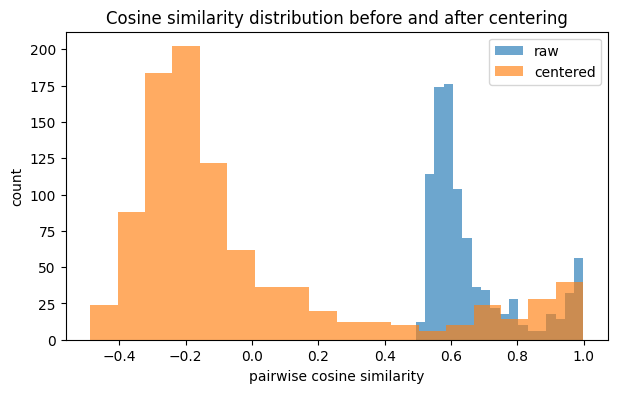

In [9]:
def off_diagonal_cosines(A):
    U = l2_normalize(A)
    G = U @ U.T
    n = G.shape[0]
    return G[~np.eye(n, dtype=bool)]

raw_cos = off_diagonal_cosines(X_scaled)
centered_cos = off_diagonal_cosines(X_centered)

plt.figure(figsize=(7, 4))
plt.hist(raw_cos, bins=18, alpha=0.65, label="raw")
plt.hist(centered_cos, bins=18, alpha=0.65, label="centered")
plt.xlabel("pairwise cosine similarity")
plt.ylabel("count")
plt.title("Cosine similarity distribution before and after centering")
plt.legend()
plt.show()


## Exercise 2

Compute the nearest neighbors of `university` before and after centering. Does centering make the neighbors more topic-specific or less topic-specific?


In [10]:
# Exercise 2 starter code
query = "university"
print("Before centering:")
display(nearest_neighbors(query, X_scaled, metric="cosine", k=6).round(3))
print("After centering:")
display(nearest_neighbors(query, X_centered, metric="cosine", k=6).round(3))


Before centering:


,neighbor,value
0,exam,0.996
1,lecture,0.996
2,teacher,0.976
3,student,0.954
4,book,0.888
5,books,0.795


After centering:


,neighbor,value
0,lecture,0.892
1,exam,0.819
2,teacher,0.730
3,student,0.714
4,book,0.430
5,books,0.325


# Part 5. PCA by SVD

Principal component analysis is a way to find directions of maximum variance.

For a centered matrix $X_c\in R^{n\times m}$, the singular value decomposition is

$$
X_c = U\Sigma V^T.
$$

The first two columns of $V$ give the first two principal directions. Two-dimensional PCA coordinates are

$$
Z_2=X_c V_2.
$$

These coordinates are useful for visualization, but they should not be overinterpreted. A two-dimensional picture can hide important high-dimensional geometry.


In [11]:
U, singular_values, Vt = np.linalg.svd(X_centered, full_matrices=False)
Z = X_centered @ Vt[:2].T
explained_variance = singular_values**2 / np.sum(singular_values**2)

print("Singular values:", np.round(singular_values, 3))
print("Explained variance ratios:", np.round(explained_variance, 3))
print("Cumulative variance in first two PCs:", round(float(explained_variance[:2].sum()), 3))

pca_df = pd.DataFrame({
    "word": words,
    "PC1": Z[:, 0],
    "PC2": Z[:, 1],
    "norm": np.linalg.norm(X_scaled, axis=1),
})
pca_df.head().round(3)


Singular values: [2.938 2.583 2.411 2.288 1.755 1.675 1.109 0.925]
Explained variance ratios: [0.251 0.194 0.169 0.153 0.09  0.082 0.036 0.025]
Cumulative variance in first two PCs: 0.446


,word,PC1,PC2,norm
0,cat,-0.670,-0.085,1.603
1,dog,-0.751,-0.070,1.598
2,lion,-1.350,-0.233,2.605
3,kitten,-0.955,-0.158,1.820
4,puppy,-0.909,-0.164,1.773


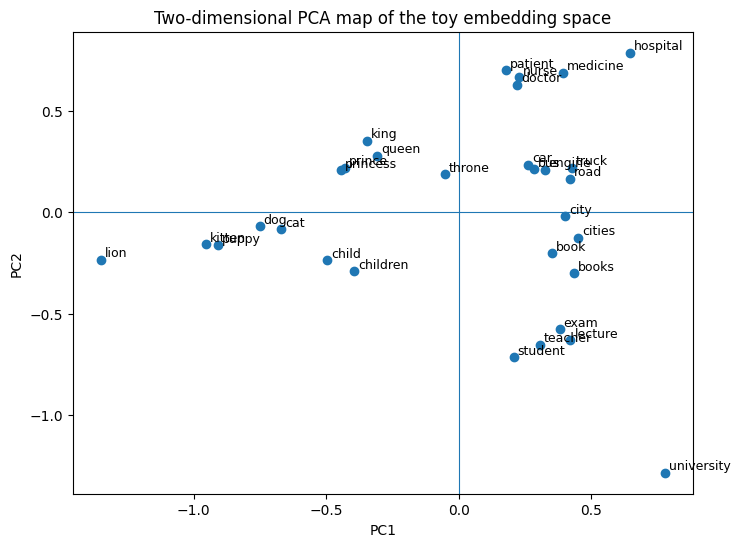

In [12]:
plt.figure(figsize=(8, 6))
plt.scatter(Z[:, 0], Z[:, 1])
for word, x, y in zip(words, Z[:, 0], Z[:, 1]):
    plt.text(x + 0.015, y + 0.015, word, fontsize=9)
plt.axhline(0, linewidth=0.8)
plt.axvline(0, linewidth=0.8)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Two-dimensional PCA map of the toy embedding space")
plt.show()


## Loading matrix

The rows of $V^T$ show how original coordinates contribute to principal components.


In [13]:
dim_names = ["animal", "vehicle", "royal", "school", "medical", "object_place", "plural", "youth_family"]
loadings = pd.DataFrame(Vt[:3].T, index=dim_names, columns=["PC1", "PC2", "PC3"])
loadings.round(3)


,PC1,PC2,PC3
animal,-0.666,-0.163,0.311
vehicle,0.239,0.130,-0.498
royal,-0.228,0.174,-0.431
school,0.313,-0.742,0.239
medical,0.253,0.581,0.641
object_place,0.386,-0.126,-0.003
plural,0.068,-0.095,0.021
youth_family,-0.363,-0.113,0.023


## Exercise 3

Use the loading matrix to interpret PC1 and PC2.

Write one or two sentences:

- Which semantic coordinates have large positive or negative weights?
- Does the two-dimensional plot separate all semantic groups equally well?


# Part 6. $k$-means clustering from scratch

The $k$-means objective is

$$
\min_{C_1,\dots,C_k,\mu_1,\dots,\mu_k}
\sum_{r=1}^k \sum_{x_i\in C_r} \|x_i-\mu_r\|_2^2.
$$

The standard algorithm alternates between two steps:

1. assign each point to its nearest centroid;
2. update each centroid to the mean of the points assigned to it.

For embeddings, this can be applied to raw vectors, centered vectors, or normalized vectors. These choices matter.


In [14]:
def kmeans(A, k, n_iter=50, seed=7243):
    local_rng = np.random.default_rng(seed)
    n = A.shape[0]
    initial = local_rng.choice(n, size=k, replace=False)
    centroids = A[initial].copy()

    for _ in range(n_iter):
        distances = np.linalg.norm(A[:, None, :] - centroids[None, :, :], axis=2)
        labels = np.argmin(distances, axis=1)

        new_centroids = centroids.copy()
        for r in range(k):
            if np.any(labels == r):
                new_centroids[r] = A[labels == r].mean(axis=0)

        if np.allclose(new_centroids, centroids):
            break
        centroids = new_centroids

    inertia = float(np.sum((A - centroids[labels]) ** 2))
    return labels, centroids, inertia

labels_raw, centroids_raw, inertia_raw = kmeans(X_centered, k=5, seed=2)
labels_unit, centroids_unit, inertia_unit = kmeans(X_centered_unit, k=5, seed=2)

cluster_table = pd.DataFrame({"word": words, "cluster_centered": labels_raw, "cluster_spherical": labels_unit})
cluster_table.sort_values(["cluster_centered", "word"])


,word,cluster_centered,cluster_spherical
25,book,0,0
26,books,0,0
28,cities,0,0
27,city,0,0
18,exam,0,0
17,lecture,0,0
15,student,0,0
16,teacher,0,0
19,university,0,0
0,cat,1,1


In [15]:
def print_clusters(labels, title):
    print(title)
    for r in sorted(set(labels)):
        cluster_words = [w for w, lab in zip(words, labels) if lab == r]
        print(f"cluster {r}:", ", ".join(cluster_words))

print_clusters(labels_raw, "k-means on centered vectors")
print()
print_clusters(labels_unit, "k-means on centered and normalized vectors")


k-means on centered vectors
cluster 0: student, teacher, lecture, exam, university, book, books, city, cities
cluster 1: cat, dog, lion, kitten, puppy, child, children
cluster 2: doctor, nurse, patient, hospital, medicine
cluster 3: car, truck, bus, road, engine
cluster 4: king, queen, prince, princess, throne

k-means on centered and normalized vectors
cluster 0: student, teacher, lecture, exam, university, book, books, city, cities
cluster 1: cat, dog, lion, kitten, puppy, child, children
cluster 2: doctor, nurse, patient, hospital, medicine
cluster 3: car, truck, bus, road, engine
cluster 4: king, queen, prince, princess, throne


## A simple cluster quality score: purity

For teaching, we use a simple known-label purity score. In real unsupervised learning, ground-truth semantic labels are often unavailable.


In [16]:
true_group = []
for w in words:
    if w in ["cat", "dog", "lion", "kitten", "puppy", "child", "children"]:
        true_group.append("animal_family")
    elif w in ["car", "truck", "bus", "road", "engine", "city", "cities"]:
        true_group.append("vehicle_place")
    elif w in ["king", "queen", "prince", "princess", "throne"]:
        true_group.append("royalty")
    elif w in ["student", "teacher", "lecture", "exam", "university", "book", "books"]:
        true_group.append("school")
    else:
        true_group.append("medicine")


def purity_score(labels, truth):
    labels = np.asarray(labels)
    truth = np.asarray(truth)
    total = 0
    for r in np.unique(labels):
        members = truth[labels == r]
        counts = pd.Series(members).value_counts()
        total += int(counts.iloc[0])
    return total / len(labels)

pd.DataFrame({
    "method": ["centered k-means", "centered + normalized k-means"],
    "inertia": [inertia_raw, inertia_unit],
    "purity": [purity_score(labels_raw, true_group), purity_score(labels_unit, true_group)],
}).round(3)


,method,inertia,purity
0,centered k-means,10.771,0.935
1,centered + normalized k-means,8.604,0.935


## Exercise 4

Run $k$-means with $k=4$, $k=5$, and $k=6$. Compare the resulting clusters.

Which value of $k$ is easiest to interpret for this toy embedding space?


In [17]:
# Exercise 4 starter code
for k in [4, 5, 6]:
    labels_k, _, inertia_k = kmeans(X_centered_unit, k=k, seed=3)
    print("\n", "=" * 40)
    print(f"k={k}, inertia={inertia_k:.3f}, purity={purity_score(labels_k, true_group):.3f}")
    print_clusters(labels_k, f"clusters for k={k}")



k=4, inertia=13.404, purity=0.774
clusters for k=4
cluster 0: student, teacher, lecture, exam, university, book, books, city, cities
cluster 1: cat, dog, lion, kitten, puppy, king, queen, prince, princess, throne, child, children
cluster 2: car, truck, bus, road, engine
cluster 3: doctor, nurse, patient, hospital, medicine

k=5, inertia=10.567, purity=0.774
clusters for k=5
cluster 0: car, truck, bus, road, engine
cluster 1: doctor, nurse, patient, hospital, medicine
cluster 2: cat, dog, lion, kitten, puppy, king, queen, prince, princess, throne, child, children
cluster 3: book, books, city, cities
cluster 4: student, teacher, lecture, exam, university

k=6, inertia=10.662, purity=0.774
clusters for k=6
cluster 0: cat, dog, lion, kitten, puppy, king, queen, prince, princess, throne, child, children
cluster 1: student, teacher, lecture, exam, university
cluster 2: book, city, cities
cluster 3: doctor, nurse, patient, medicine
cluster 4: car, truck, bus, road, engine
cluster 5: hospital

# Part 7. Distance concentration in high dimensions

For random points in high-dimensional space, pairwise distances often become relatively similar. One way to quantify this is the coefficient of variation:

$$
\mathrm{CV}=\frac{\operatorname{std}(D)}{\operatorname{mean}(D)},
$$

where $D$ is the random distance between two points.

If $\mathrm{CV}$ is small, distances are concentrated around their mean.


In [18]:
def distance_summary(dim, n_pairs=5000, seed=9):
    local_rng = np.random.default_rng(seed + dim)
    A = local_rng.normal(size=(n_pairs, dim))
    B = local_rng.normal(size=(n_pairs, dim))
    distances = np.linalg.norm(A - B, axis=1)
    return distances.mean(), distances.std(), distances.std() / distances.mean()

dims = [2, 5, 10, 25, 50, 100, 300, 768]
rows = []
for dim in dims:
    mean_d, std_d, cv = distance_summary(dim)
    rows.append({"dimension": dim, "mean distance": mean_d, "std distance": std_d, "coefficient of variation": cv})

distance_df = pd.DataFrame(rows)
distance_df.round(4)


,dimension,mean distance,std distance,coefficient of variation
0,2,1.7539,0.9243,0.5270
1,5,3.0043,0.9709,0.3232
2,10,4.3484,0.9835,0.2262
3,25,7.0095,1.0062,0.1435
4,50,9.9335,1.0059,0.1013
5,100,14.1167,0.9814,0.0695
6,300,24.4852,0.9903,0.0404
7,768,39.1863,0.9937,0.0254


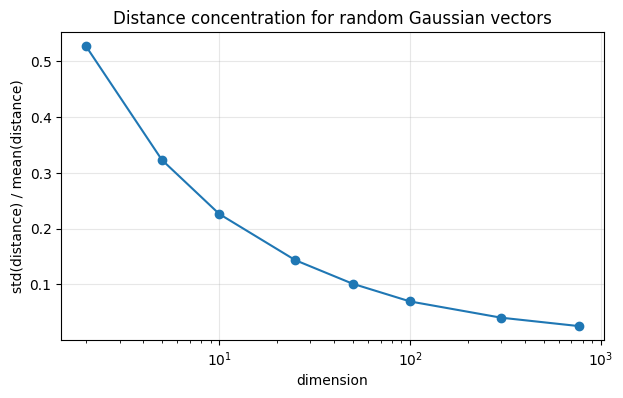

In [19]:
plt.figure(figsize=(7, 4))
plt.plot(distance_df["dimension"], distance_df["coefficient of variation"], marker="o")
plt.xscale("log")
plt.xlabel("dimension")
plt.ylabel("std(distance) / mean(distance)")
plt.title("Distance concentration for random Gaussian vectors")
plt.grid(True, alpha=0.3)
plt.show()


## Interpretation

Distance concentration does **not** mean high-dimensional embeddings are useless. Learned embeddings are not random Gaussian point clouds. The lesson is more careful:

> Meaningful high-dimensional similarity must come from learned structure, not from dimension alone.


# Part 8. Hubness in nearest-neighbor search

A **hub** is a point that appears in many other points' nearest-neighbor lists.

Hubness is common in high-dimensional spaces. It can make retrieval less diverse: the same few vectors may appear as neighbors for many unrelated queries.


In [20]:
def knn_indegree(A, k=5):
    U = l2_normalize(A)
    S = U @ U.T
    np.fill_diagonal(S, -np.inf)
    neighbors = np.argsort(-S, axis=1)[:, :k]
    indegree = np.zeros(A.shape[0], dtype=int)
    for row in neighbors:
        for j in row:
            indegree[j] += 1
    return indegree, neighbors


def gini(x):
    x = np.asarray(x, dtype=float)
    if np.allclose(x.sum(), 0):
        return 0.0
    sorted_x = np.sort(x)
    n = len(x)
    cum = np.cumsum(sorted_x)
    return float((n + 1 - 2 * np.sum(cum) / cum[-1]) / n)

indegree_raw, neighbors_raw = knn_indegree(X_scaled, k=5)
indegree_centered, neighbors_centered = knn_indegree(X_centered, k=5)

hub_df = pd.DataFrame({
    "word": words,
    "kNN indegree raw": indegree_raw,
    "kNN indegree centered": indegree_centered,
    "norm": np.linalg.norm(X_scaled, axis=1),
}).sort_values("kNN indegree raw", ascending=False)

print("Gini of raw kNN indegree:", round(gini(indegree_raw), 3))
print("Gini of centered kNN indegree:", round(gini(indegree_centered), 3))
hub_df.head(12)


Gini of raw kNN indegree: 0.192
Gini of centered kNN indegree: 0.158


,word,kNN indegree raw,kNN indegree centered,norm
25,book,13,7,1.449598
27,city,9,11,1.579106
29,child,9,10,1.604544
9,engine,6,5,1.538947
3,kitten,6,6,1.820344
4,puppy,6,6,1.773181
8,road,6,6,1.582995
18,exam,6,5,1.529231
17,lecture,6,6,1.663067
15,student,5,5,1.628118


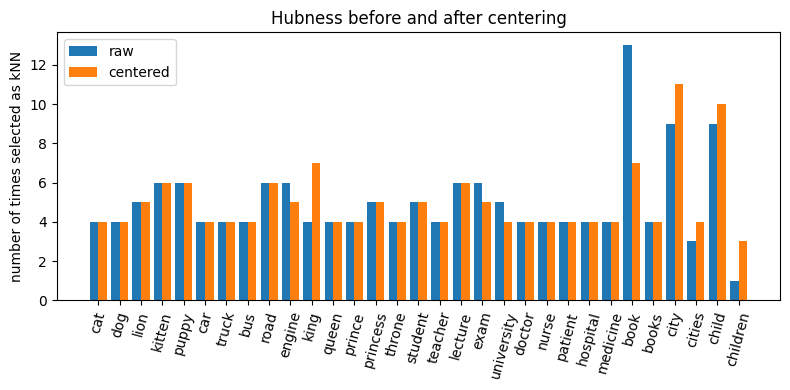

In [21]:
plt.figure(figsize=(8, 4))
positions = np.arange(len(words))
plt.bar(positions - 0.2, indegree_raw, width=0.4, label="raw")
plt.bar(positions + 0.2, indegree_centered, width=0.4, label="centered")
plt.xticks(positions, words, rotation=75)
plt.ylabel("number of times selected as kNN")
plt.title("Hubness before and after centering")
plt.legend()
plt.tight_layout()
plt.show()


## Exercise 5

Change the number of neighbors from $k=5$ to $k=3$ and $k=8$. Does the same word remain a hub?


In [22]:
# Exercise 5 starter code
for k in [3, 8]:
    indeg, _ = knn_indegree(X_scaled, k=k)
    top = pd.DataFrame({"word": words, "indegree": indeg}).sort_values("indegree", ascending=False).head(5)
    print(f"\nTop hubs for k={k}")
    display(top)



Top hubs for k=3


,word,indegree
4,puppy,6
18,exam,5
1,dog,4
11,queen,4
10,king,4



Top hubs for k=8


,word,indegree
25,book,22
27,city,19
8,road,16
28,cities,12
26,books,12


# Part 9. Semantic directions and projection

Many embedding analyses use vector differences to estimate directions. For example, a toy plural direction can be estimated by averaging differences:

$$
b = \frac{1}{r}\sum_{i=1}^r (e_{plural_i}-e_{singular_i}).
$$

After normalizing $b$, the projection score of a word vector $x$ onto this direction is

$$
s(x)=x^T b.
$$

Large scores suggest that $x$ lies far in the positive direction.


In [23]:
word_index = {w: i for i, w in enumerate(words)}

plural_pairs = [("book", "books"), ("city", "cities"), ("child", "children")]
plural_direction = np.zeros(X_centered.shape[1])
for singular, plural in plural_pairs:
    plural_direction += X_centered[word_index[plural]] - X_centered[word_index[singular]]
plural_direction /= len(plural_pairs)
plural_direction /= np.linalg.norm(plural_direction)

plural_scores = X_centered @ plural_direction
plural_df = pd.DataFrame({"word": words, "projection_on_plural_direction": plural_scores})
plural_df.sort_values("projection_on_plural_direction", ascending=False).round(3).head(12)


,word,projection_on_plural_direction
30,children,0.780
28,cities,0.777
26,books,0.754
19,university,0.028
23,hospital,0.026
14,throne,-0.004
6,truck,-0.008
25,book,-0.057
8,road,-0.062
18,exam,-0.065


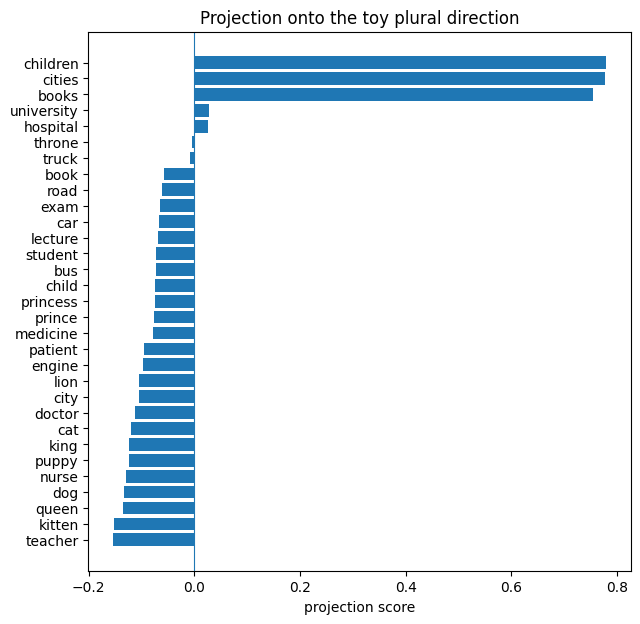

In [24]:
ordered = plural_df.sort_values("projection_on_plural_direction")
plt.figure(figsize=(7, 7))
plt.barh(ordered["word"], ordered["projection_on_plural_direction"])
plt.axvline(0, linewidth=0.8)
plt.xlabel("projection score")
plt.title("Projection onto the toy plural direction")
plt.show()


## Removing a direction by projection

Given a unit vector $b$, the component of $x$ along $b$ is

$$
(x^Tb)b.
$$

The residual after removing that direction is

$$
x_{res}=x-(x^Tb)b.
$$

This idea appears in some mathematical sketches of embedding debiasing. In this lab, we use a non-sensitive toy plural direction to focus on linear algebra.


In [25]:
def remove_direction(A, direction):
    b = direction / np.linalg.norm(direction)
    return A - (A @ b)[:, None] * b[None, :]

X_without_plural = remove_direction(X_centered, plural_direction)
new_plural_scores = X_without_plural @ plural_direction

pd.DataFrame({
    "word": words,
    "before": plural_scores,
    "after removing plural direction": new_plural_scores,
}).sort_values("before", ascending=False).round(4).head(12)


,word,before,after removing plural direction
30,children,0.7796,0.0
28,cities,0.7771,-0.0
26,books,0.7541,-0.0
19,university,0.0283,0.0
23,hospital,0.0260,0.0
14,throne,-0.0041,0.0
6,truck,-0.0082,-0.0
25,book,-0.0572,-0.0
8,road,-0.0621,-0.0
18,exam,-0.0647,-0.0


## Exercise 6

Construct a different direction, such as a `royal` direction or a `medical` direction, using pairs or group centroids.

For example, you can compare the mean of royal words with the mean of non-royal words:

$$
b = \mu_{royal}-\mu_{other}.
$$

Then rank all words by projection score.


In [26]:
# Exercise 6 starter code: build a royal direction from group means
royal_words = ["king", "queen", "prince", "princess", "throne"]
other_words = [w for w in words if w not in royal_words]

royal_mean = X_centered[[word_index[w] for w in royal_words]].mean(axis=0)
other_mean = X_centered[[word_index[w] for w in other_words]].mean(axis=0)
royal_direction = royal_mean - other_mean
royal_direction = royal_direction / np.linalg.norm(royal_direction)

royal_scores = X_centered @ royal_direction
pd.DataFrame({"word": words, "royal_score": royal_scores}).sort_values("royal_score", ascending=False).round(3).head(10)


,word,royal_score
12,prince,0.998
14,throne,0.983
10,king,0.978
11,queen,0.978
13,princess,0.866
29,child,0.040
2,lion,-0.038
30,children,-0.072
3,kitten,-0.080
4,puppy,-0.098


# Part 10. A small contextual-embedding thought experiment

Static embeddings give one vector per word type. Contextual embeddings give a vector that depends on the sentence.

For example, the word `bank` can mean a financial institution or a river side. A static model must compress both senses into one vector. A contextual model can place the two occurrences in different regions.

We simulate this by building simple sentence-context vectors from hand-made word vectors.


In [27]:
context_vectors = {
    "money":    np.array([0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0]),
    "loan":     np.array([0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.1, 1.0]),
    "account":  np.array([0.0, 0.0, 0.0, 0.0, 0.0, 0.1, 0.0, 1.0]),
    "river":    np.array([0.0, 0.6, 0.0, 0.0, 0.0, 0.8, 0.0, 0.0]),
    "water":    np.array([0.0, 0.5, 0.0, 0.0, 0.0, 0.9, 0.0, 0.0]),
    "shore":    np.array([0.0, 0.4, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0]),
}

static_bank = np.array([0.0, 0.25, 0.0, 0.0, 0.0, 0.45, 0.0, 0.50])

sentences = {
    "financial bank": ["bank", "money", "loan", "account"],
    "river bank": ["bank", "river", "water", "shore"],
}

contextual = {}
for name, toks in sentences.items():
    vecs = []
    for tok in toks:
        vecs.append(static_bank if tok == "bank" else context_vectors[tok])
    contextual[name] = np.mean(vecs, axis=0)

context_names = ["static bank", "financial bank", "river bank", "money", "river"]
context_matrix = np.vstack([
    static_bank,
    contextual["financial bank"],
    contextual["river bank"],
    context_vectors["money"],
    context_vectors["river"],
])

S_context = l2_normalize(context_matrix) @ l2_normalize(context_matrix).T
pd.DataFrame(S_context, index=context_names, columns=context_names).round(3)


,static bank,financial bank,river bank,money,river
static bank,1.000,0.808,0.806,0.697,0.711
financial bank,0.808,1.000,0.303,0.985,0.166
river bank,0.806,0.303,1.000,0.137,0.981
money,0.697,0.985,0.137,1.000,0.000
river,0.711,0.166,0.981,0.000,1.000


## Interpretation

The two contextual versions of `bank` have different nearest neighbors, even though they share the same surface word. This is one reason modern transformer embeddings are contextual rather than static.


# Part 11. AI-assisted learning component

Use an AI assistant as a mathematical critic, not just as a code generator.

Try these prompts after completing the lab:

1. **Metric audit.**  
   "I compared cosine, inner-product, and Euclidean nearest neighbors for a toy embedding space. Give me a checklist for deciding which metric is appropriate in an NLP retrieval system."

2. **PCA critique.**  
   "Here is a two-dimensional PCA plot of embeddings. What are three ways this visualization could be misleading?"

3. **Hubness debugging.**  
   "Several words appear as nearest neighbors for many unrelated queries. Explain hubness and suggest diagnostics."

4. **Projection analysis.**  
   "I estimated a semantic direction by averaging vector differences. What sensitivity tests should I perform before trusting the interpretation?"

5. **Independent study reflection.**  
   "Explain the identity $\|u-v\|^2=2-2\cos(u,v)$ for unit vectors in a way suitable for a first-year graduate student in applied mathematics."


# Part 12. Mini-project: metric sensitivity of embeddings

Choose one of the following mini-projects.

## Option A. Metric sensitivity report

Use the toy embeddings in this notebook.

1. Pick five query words.
2. Compute top-5 neighbors using cosine, inner product, and Euclidean distance.
3. Identify which queries are stable across metrics and which are unstable.
4. Explain instability using vector norms, centering, or group structure.
5. Write a short recommendation: which metric would you use for this embedding space?

## Option B. Build your own toy embedding space

Create a new vocabulary with at least 25 words from three or more themes. Construct an embedding matrix manually or from co-occurrence counts.

Then repeat:

1. nearest-neighbor comparison;
2. PCA visualization;
3. $k$-means clustering;
4. semantic direction analysis.

## Option C. Geometry audit for a real model

After learning how to load pretrained embeddings, repeat the same analysis on a real embedding model.

At minimum, report:

- mean pairwise cosine similarity;
- nearest-neighbor examples;
- hubness statistics;
- PCA plot;
- at least one semantic direction test.


# Summary

In this lab, you learned that embedding geometry depends on mathematical choices.

Key ideas:

- Embeddings form a point cloud $X\in R^{n\times m}$.
- Inner product, cosine similarity, and Euclidean distance answer different geometric questions.
- Length-normalization makes cosine and Euclidean ranking equivalent.
- Centering can reduce a common mean direction and reveal more contrast.
- PCA is an SVD-based visualization tool, not a proof of semantic structure.
- $k$-means clustering depends on preprocessing and metric choice.
- High-dimensional spaces can exhibit distance concentration and hubness.
- Semantic directions are useful but require sensitivity tests and careful interpretation.

The next labs will move from static geometry toward neural models that learn embeddings as part of a supervised or self-supervised objective.
